In [ ]:
import pandas as pd
import glob
import os


# Load CSV file
def load_pf_csv(file_path):
    df_raw = pd.read_csv(file_path, header=None)

    elem_row = df_raw.iloc[0].fillna("")
    var_row = df_raw.iloc[1].fillna("")

    combined_cols = []

    # Combine headers
    for e, v in zip(elem_row, var_row):
        e = str(e).strip()
        v = str(v).strip()

        if e and v:
            name = f"{e}_{v}"
        elif e:
            name = e
        elif v:
            name = v
        else:
            name = "unnamed"

        combined_cols.append(name)

    df = df_raw.iloc[2:].reset_index(drop=True)
    df.columns = combined_cols

    return df

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_fft_from_pf(file_path, column_substring="u1, Magnitude in p.u.", tmax=None, plot=False, fmax=5.0):
    df = load_pf_csv(file_path)

    # Time column
    time_col = [c for c in df.columns if "Time in s" in c][0]
    t = df[time_col].astype(float).values

    # Select signal
    target_cols = [c for c in df.columns if column_substring in c]

    if len(target_cols) == 0:
        print(f"No match for substring: {column_substring}")
        return {}

    col = target_cols[0]
    x = df[col].astype(float).values

    # Trim window
    if tmax is not None:
        mask = t <= tmax
        t = t[mask]
        x = x[mask]

    # Remove mean
    x_detrended = x - np.mean(x)

    # Compute FFT
    N = len(x_detrended)
    dt = t[1] - t[0]
    freqs = np.fft.rfftfreq(N, d=dt)
    fft_vals = np.abs(np.fft.rfft(x_detrended))

    # Plot spectrum
    if plot:
        mask = freqs <= fmax

        plt.figure(figsize=(8, 4))
        plt.plot(freqs[mask], fft_vals[mask])
        plt.title(f"FFT (detrended) of {col}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.grid()
        plt.show()

    return {
        "column": col,
        "freqs": freqs,
        "fft": fft_vals
    }

In [ ]:
summary_path = r"C:\Users\M Hasan Rosyid\Desktop\Dataset_Project\LHS\LHS\results_summary_lhs.csv"
summary = pd.read_csv(summary_path)
summary.columns = summary.columns.str.strip()

# Flag-one cases
flag1_cases = summary[summary["flag"] == 1]

# Check count
print("Total flag=1 cases:", len(flag1_cases))

# Sample cases
sampled_cases = flag1_cases.sample(5, random_state=42)
print(sampled_cases)

# Rebuild filenames
def build_filename(row):
    sim = int(row["Simulation no#"])
    line_text = row["Line"].replace(" ", "")
    load = row["Load"]
    w1, w2, w3 = row["Wind1"], row["Wind2"], row["Wind3"]

    return f"{sim}_{row['Line']}_load={load}_wind={w1}_{w2}_{w3}.csv"

sampled_cases["filename"] = sampled_cases.apply(build_filename, axis=1)

print("\nGenerated filenames:")
for f in sampled_cases["filename"]:
    print(f)

# Match file paths
folder = r"C:\Users\M Hasan Rosyid\Desktop\Dataset_Project\LHS\LHS"

file_paths1 = []
for fname in sampled_cases["filename"]:
    matches = glob.glob(os.path.join(folder, "**", fname), recursive=True)
    file_paths1.append(matches)

print("\nMatched file paths:")
for p in file_paths1:
    print(p)

Total flag=1 cases: 19650
       Simulation no#          Line    Load   Wind1   Wind2   Wind3  flag  \
44884           660.0  Line 06 - 11  0.8744  0.5486  0.1255  0.5235   1.0   
53826           791.0  Line 01 - 02  0.9792  0.6269  0.4446  0.0840   1.0   
51640           759.0  Line 21 - 22  1.1188  0.6378  0.4296  0.7459   1.0   
17284           254.0  Line 16 - 19  0.8309  0.3514  0.7276  0.5139   1.0   
97476          1433.0  Line 08 - 09  0.8967  0.1262  0.2289  0.3112   1.0   

                                                Sequence  
44884  [('Line 06 - 11DR1', '1.04'), ('Line 06 - 11DR...  
53826  [('Line 01 - 02DR2', '1.04'), ('Line 01 - 02DR...  
51640  [('Line 21 - 22DR1', '1.04'), ('Line 21 - 22DR...  
17284  [('Line 16 - 19DR1', '1.04'), ('Line 16 - 19DR...  
97476  [('Line 08 - 09DR1', '1.04'), ('Line 08 - 09DR...  

Generated filenames:
660_Line 06 - 11_load=0.8744_wind=0.5486_0.1255_0.5235.csv
791_Line 01 - 02_load=0.9792_wind=0.6269_0.4446_0.084.csv
759_Line 21 - 22_l

In [8]:
for p in file_paths1:
    print(compute_fft_from_pf(p[0], plot=True))

{}
{}


C:\Users\M Hasan Rosyid\AppData\Local\Temp\ipykernel_13944\205825987.py:14: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251) ha

{}
{}
{}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def compute_fft_speed(file_path, col_substr="G 01_Speed in p.u.", tmax=None, plot=False):
    df = load_pf_csv(file_path)

    # Time column
    time_col = [c for c in df.columns if "Time in s" in c][0]
    t = df[time_col].astype(float).values

    # Speed column
    cols = [c for c in df.columns if col_substr in c]

    if not cols:
        print("No speed column found")
        return {}

    col = cols[0]
    x = df[col].astype(float).values

    # Trim window
    if tmax is not None:
        mask = t <= tmax
        t = t[mask]
        x = x[mask]

    # Remove mean
    x_detr = x - np.mean(x)

    # Compute FFT
    N = len(x_detr)
    dt = t[1] - t[0]
    freqs = np.fft.rfftfreq(N, d=dt)
    fft_vals = np.abs(np.fft.rfft(x_detr))

    if plot:
        # Low frequencies
        fmax = 5.0
        mask_f = freqs <= fmax

        plt.figure(figsize=(8, 4))
        plt.plot(freqs[mask_f], fft_vals[mask_f])
        plt.title(f"FFT (detrended) of {col}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.grid(True)
        plt.show()

    return {"column": col, "freqs": freqs, "fft": fft_vals}

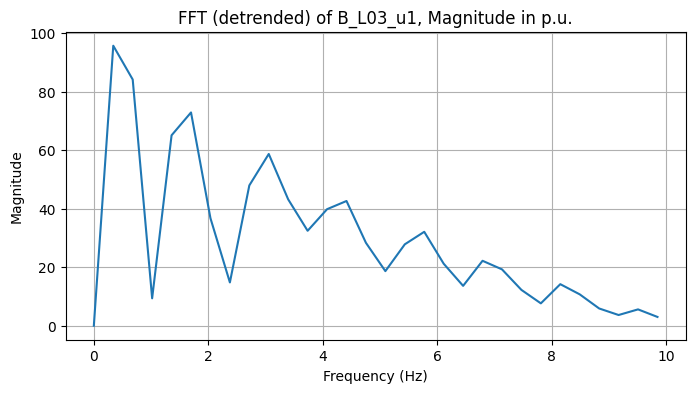

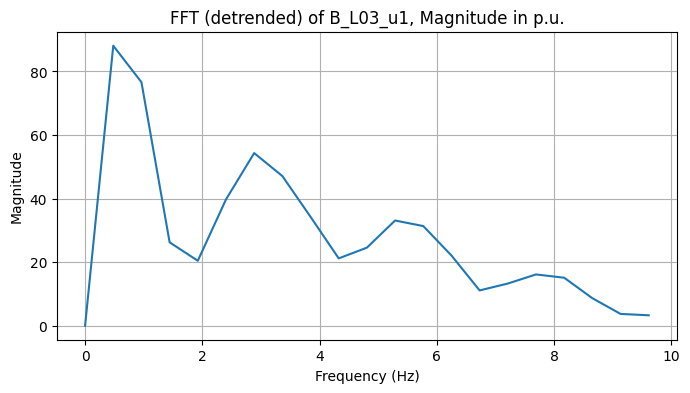

C:\Users\M Hasan Rosyid\AppData\Local\Temp\ipykernel_13944\205825987.py:14: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251) ha

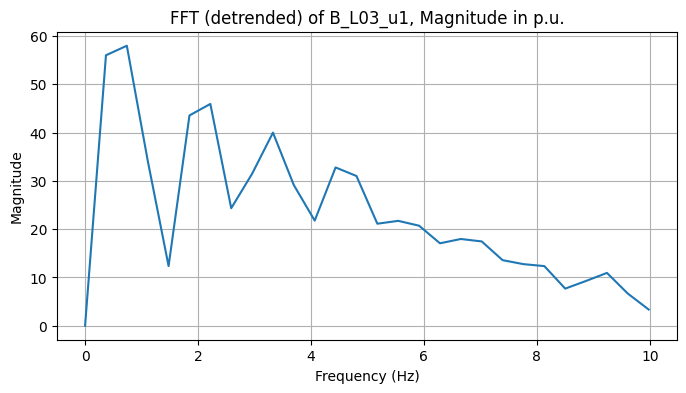

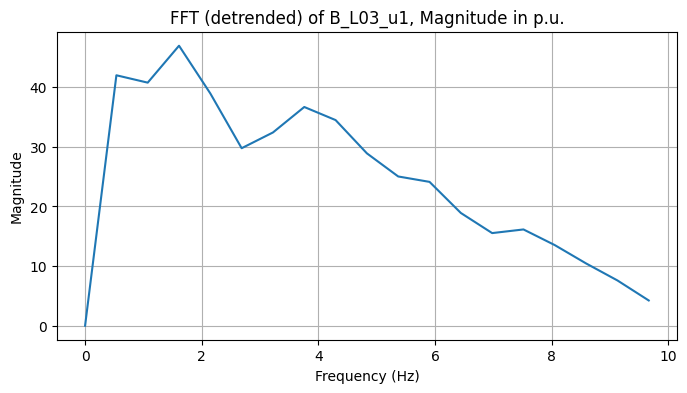

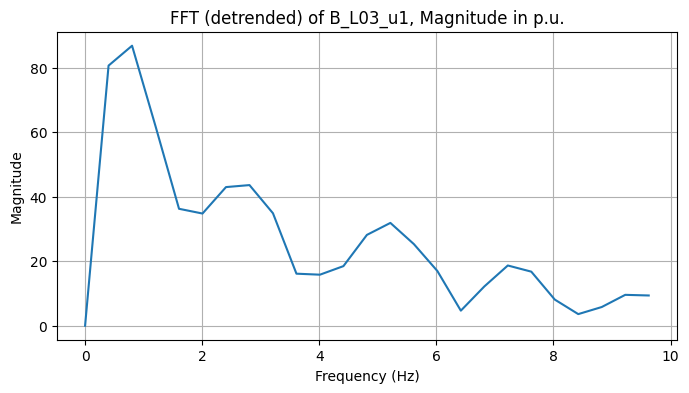

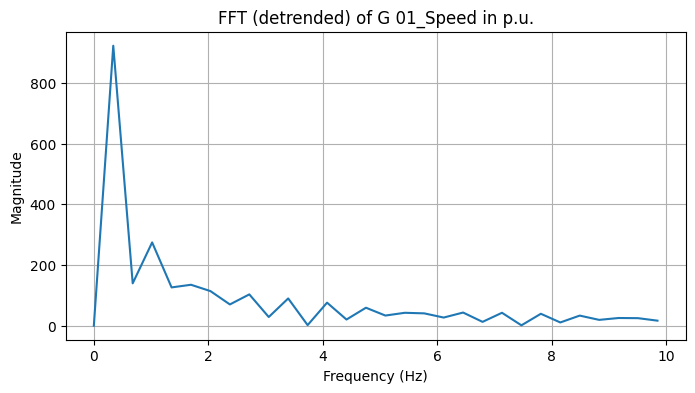

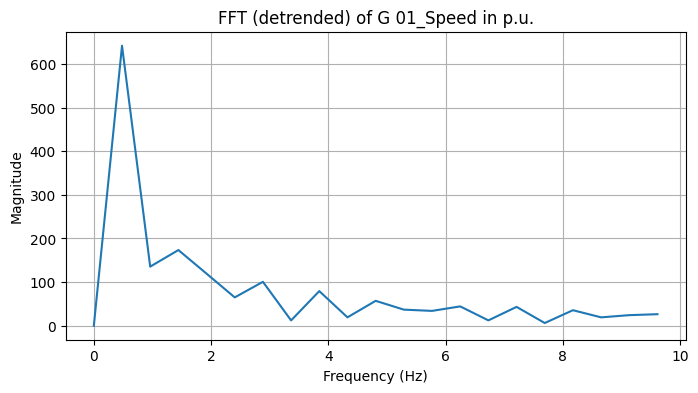

C:\Users\M Hasan Rosyid\AppData\Local\Temp\ipykernel_13944\205825987.py:14: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251) ha

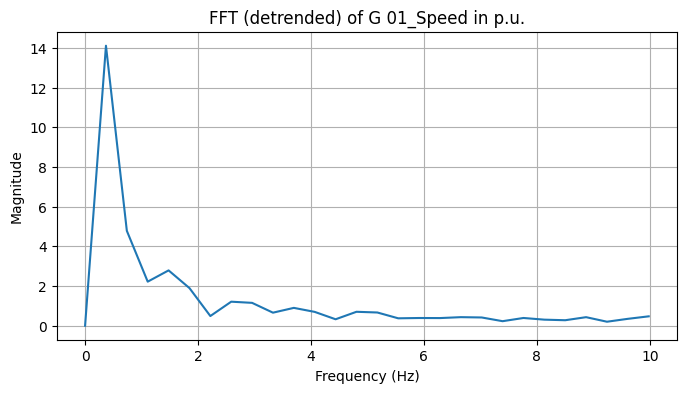

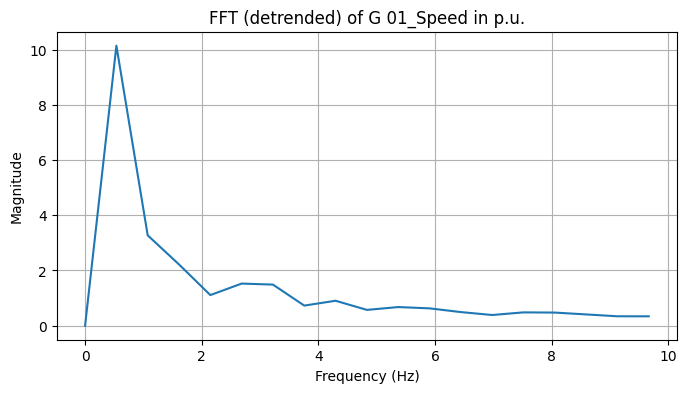

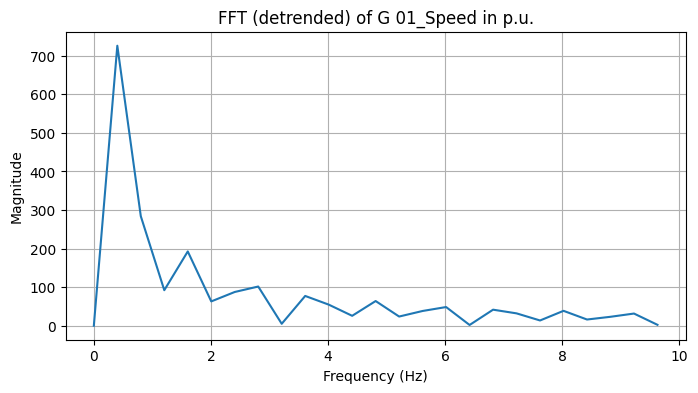

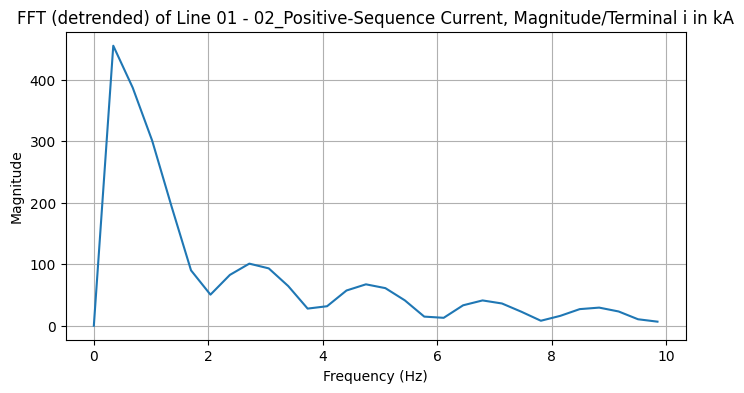

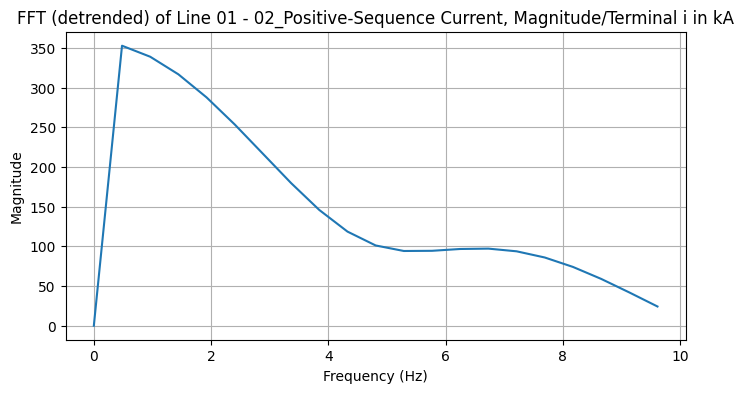

C:\Users\M Hasan Rosyid\AppData\Local\Temp\ipykernel_13944\205825987.py:14: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251) ha

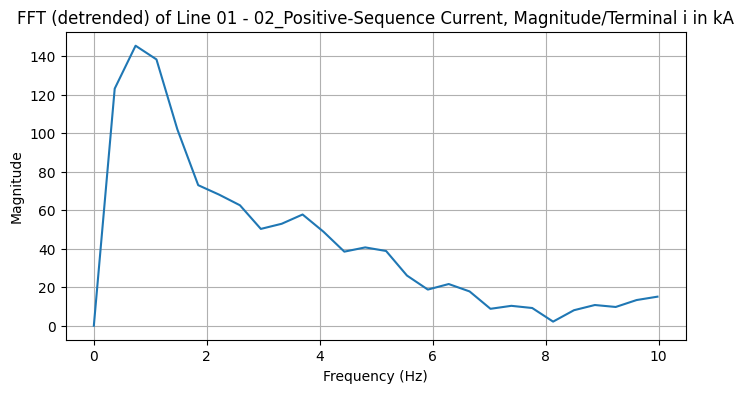

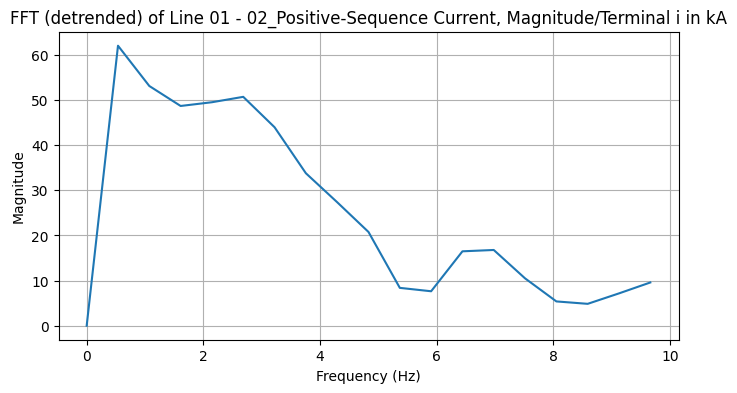

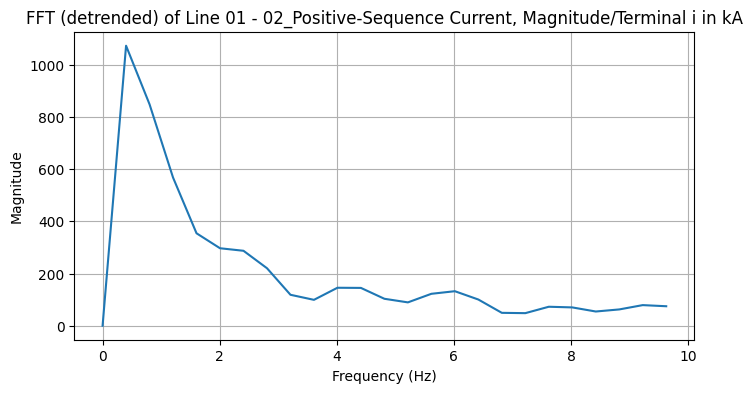

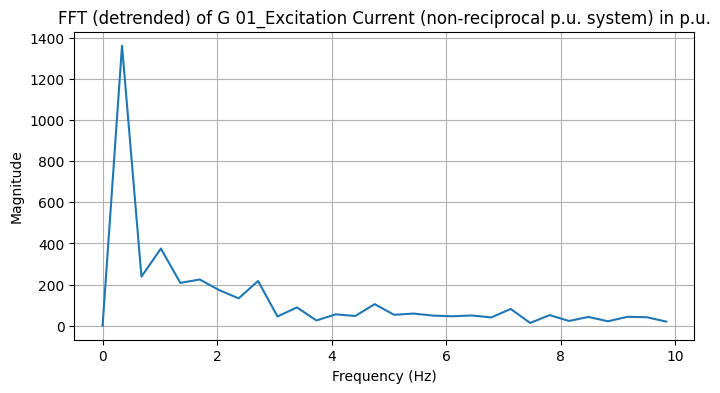

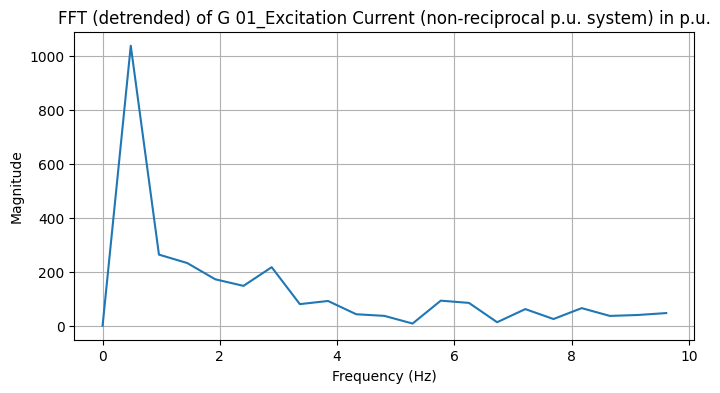

C:\Users\M Hasan Rosyid\AppData\Local\Temp\ipykernel_13944\205825987.py:14: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251) ha

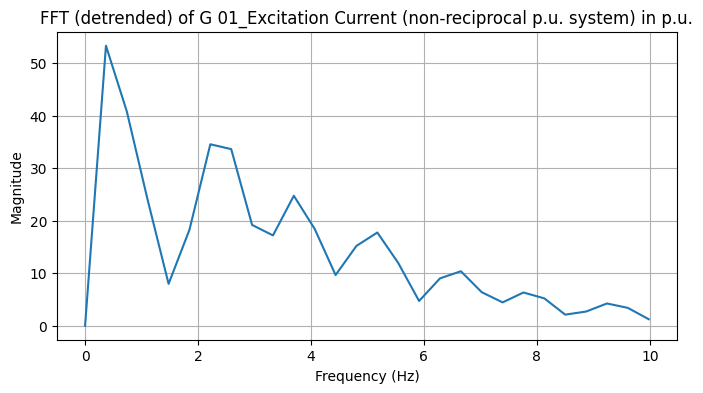

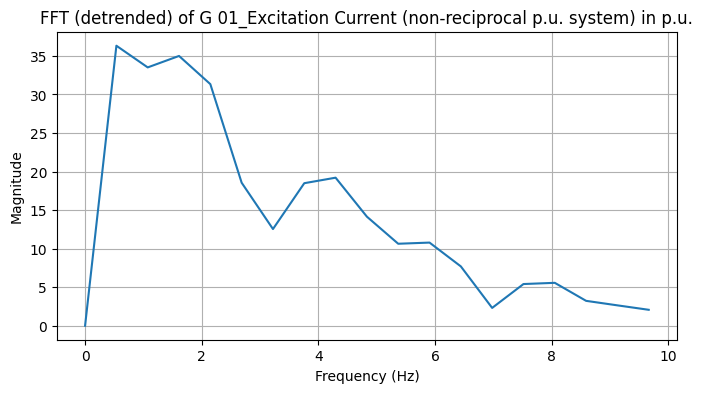

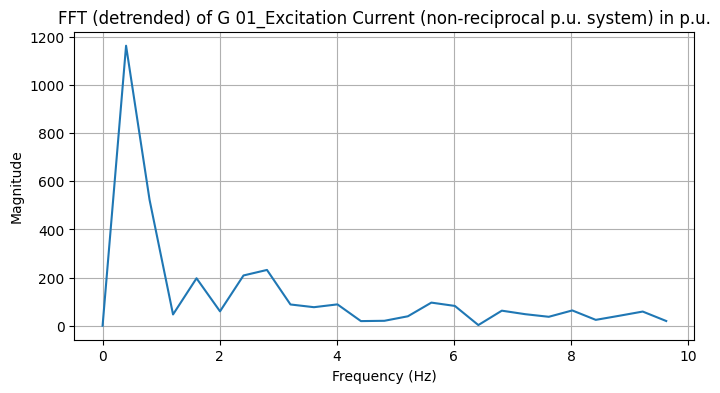

In [ ]:
column_sub=["u1, Magnitude in p.u.", "Speed in p.u.", "Positive-Sequence Current", "Excitation Current"]
for f in column_sub:
    for p in file_paths1:
        compute_fft_from_pf(p[0], column_substring=f, tmax=50, plot=True, fmax=30)


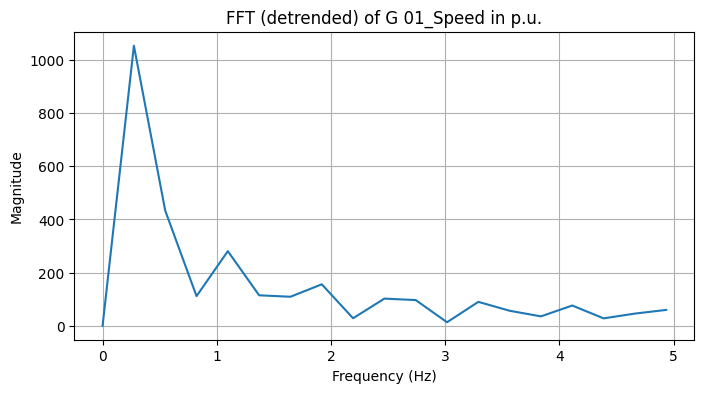

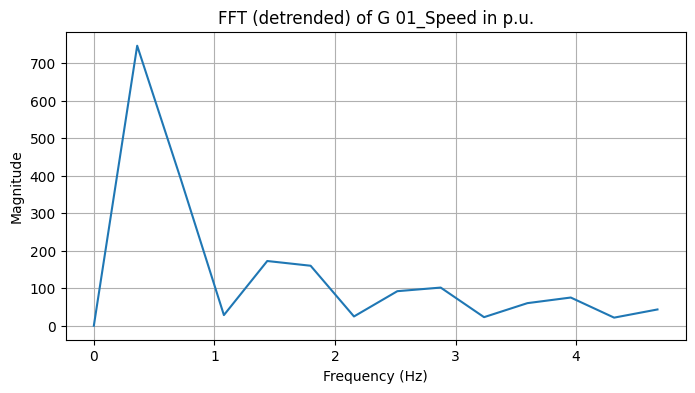

C:\Users\M Hasan Rosyid\AppData\Local\Temp\ipykernel_13944\205825987.py:14: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251) ha

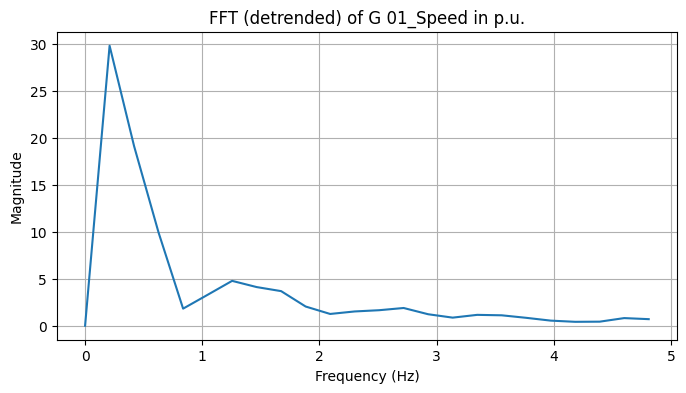

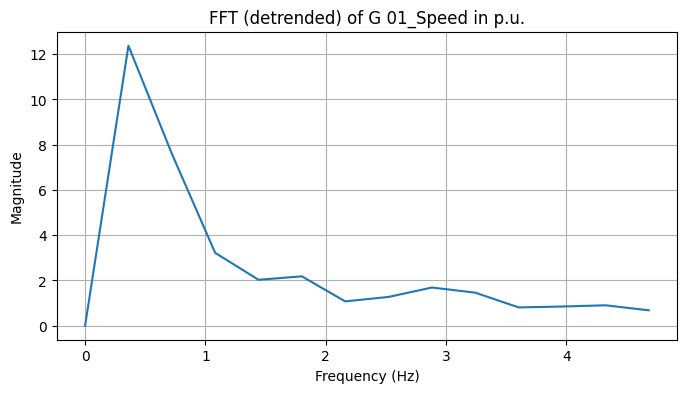

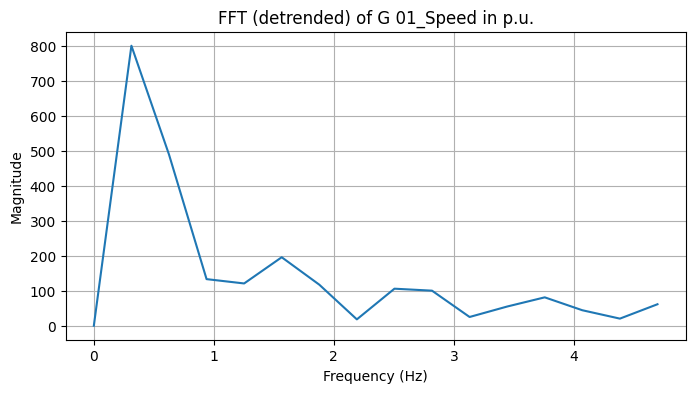

In [18]:
for p in file_paths1:
    compute_fft_speed(p[0], plot=True)
